<a href="https://colab.research.google.com/github/fiapostechfase1/tech-challenge/blob/Erick/Tech_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge - Análise de Exportação de Vinho Brasileiro

## 1. Descrição do Problema

<p>Imagine agora, que você vai atuar como Expert em Data Analytics em uma
empresa que exporta vinhos do Brasil para o mundo todo.
Sua área é recém-criada dentro da empresa, e você será responsável
pelos relatórios iniciais a serem apresentados em uma reunião de investidores e
acionistas, explicando a quantidade de vinhos exportados e os fatores externos
que podem vir a surgir e que interferem nas análises:</p>
<ul>
    <li>1. Dados climáticos. </li>
    <li>2. Dados demográficos.</li>
    <li>3. Dados econômicos.</li>
    <li>4. Dados de avaliações de vinhos.</li>
</ul>

<p>O Head de Dados pediu para que você construísse uma tabela contendo
as seguintes informações:</p>
<ul>
    <li>a. País de origem (Brasil). </li>
    <li>b. País de destino. </li>
    <li>c. Quantidade em litros de vinho exportado (utilize: 1KG =1L). </li>
    <li>d. Valor em US$. </li>
</ul>

<p>Os dados que lhe forneceram são de uma vinícola parceira, e podem ser
encontrados aqui: http://vitibrasil.cnpuv.embrapa.br/index.php?opcao=opt_01
</br>Seu objetivo é dizer o montante de venda de exportação nos últimos 15
anos, separando a análise por país e trazendo quais as prospecções futuras e
possíveis ações para uma melhoria nas exportações. Construa gráficos atraentes e que passem a ideia central para que os acionistas e investidores
possam seguir em frente com suas ações.</p>

## 2. Carregando Dados

### 2.1 Importando Bibliotecas Necessárias

Inicio o projeto importando as bibliotecas que serão utilizadas para o tratamento e a visualização de dados.

In [ ]:
# importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 2.2 Carregando dados

Trazendo a base de dados de exportação de vinhos para o projeto.

In [ ]:
# importando datasets
dados = pd.read_csv('https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Erick/dados/ExpVinho.csv', sep = '\t')

cotacao = pd.read_csv('https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Erick/dados/USD_BRL%20Dados%20Hist%C3%B3ricos.csv', sep = ',')

In [ ]:
# primeira visualização do dataset
dados.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# visualização da cotação mensal do dólar
cotacao.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,01.12.2024,"6,1778","6,0002","6,3144","5,8665",NaN,"3,43%"
1,01.11.2024,"5,9730","5,7885","6,1159","5,6335",NaN,"3,22%"
2,01.10.2024,"5,7867","5,4501","5,7949","5,4037",NaN,"6,21%"
3,01.09.2024,"5,4482","5,6464","5,6769","5,3938",NaN,"-2,89%"
4,01.08.2024,"5,6103","5,6507","5,8648","5,3755",NaN,"-0,70%"


## 3. Preparando Dados Para Análise

Nessa etapa é feita a transformação dos dados necessárias, para que os dados estejam padronizados e prontos para que sejam criadas as primeiras visualizações.

### 3.1 Visão Geral dos Dados

Entendendo melhor os dados disponíveis, e transformando-os para que possam suprir as necessidades de visualização para responder as perguntas norteadoras.

#### 3.1.1 Tratando os Dados de **Exportação**

In [ ]:
# entendendo as dimensões do DataFrame
dados.shape

(141, 112)

In [ ]:
# separando colunas em lista, excluindo Id e País
colunas = dados.columns.tolist()
colunas_anos = [col for col in colunas if col not in ['Id', 'País']]

In [ ]:
# selecionando a primeira aparição de ano como Quantidade(Kg) e a segunda como Valor(US$)
colunas_quantidade = colunas_anos[::2]
colunas_valor = colunas_anos[1::2]

In [ ]:
# separando as colunas da base de dados: Quantidade
dados_quantidade = dados[['País'] + colunas_quantidade].melt(id_vars='País', var_name='Ano', value_name='Quantidade')
dados_quantidade.head()

,País,Ano,Quantidade
0,Afeganistão,1970,0
1,África do Sul,1970,0
2,"Alemanha, República Democrática",1970,0
3,Angola,1970,0
4,Anguilla,1970,0


In [ ]:
# separando as colunas da base de dados: Valor
dados_valor = dados[['País'] + colunas_valor].copy()
dados_valor.columns = ['País'] + colunas_quantidade
dados_valor = dados_valor.melt(id_vars='País', var_name='Ano', value_name='Valor')
dados_valor.head()

,País,Ano,Valor
0,Afeganistão,1970,0
1,África do Sul,1970,0
2,"Alemanha, República Democrática",1970,0
3,Angola,1970,0
4,Anguilla,1970,0


In [ ]:
# unificando as tabelas de Quantidade e Valor em uma única tabela
dados_final = pd.merge(dados_quantidade, dados_valor, on=['País', 'Ano'])

In [ ]:
# exibindo a tabela final
dados_final.head()

,País,Ano,Quantidade,Valor
0,Afeganistão,1970,0,0
1,África do Sul,1970,0,0
2,"Alemanha, República Democrática",1970,0,0
3,Angola,1970,0,0
4,Anguilla,1970,0,0


In [ ]:
# selecionando apenas os resultados dos últimos 15 anos com relação ao DataFrame, ou seja, entre 2010 e 2024
dados_final['Ano'] = pd.to_numeric(dados_final['Ano'], errors='coerce')
ano_max = dados_final['Ano'].max()
anos_recente = dados_final[dados_final['Ano'] >= ano_max - 14]
anos_recente.head()

,País,Ano,Quantidade,Valor
5640,Afeganistão,2010,0,0
5641,África do Sul,2010,0,0
5642,"Alemanha, República Democrática",2010,27715,138666
5643,Angola,2010,33557,189891
5644,Anguilla,2010,0,0


In [ ]:
# reestruturando os nomes dos países
anos_recente.reset_index(drop = True, inplace = True)
anos_recente['País'] = anos_recente['País'].str.replace(r',.*', '', regex=True)
anos_recente.head()

<ipython-input-35-20c8d7186004>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anos_recente['País'] = anos_recente['País'].str.replace(r',.*', '', regex=True)


,País,Ano,Quantidade,Valor
0,Afeganistão,2010,0,0
1,África do Sul,2010,0,0
2,Alemanha,2010,27715,138666
3,Angola,2010,33557,189891
4,Anguilla,2010,0,0


In [ ]:
# entendendo a estruturação do novo formato do DataFrame
anos_recente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2115 entries, 0 to 2114
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   País        2115 non-null   object
 1   Ano         2115 non-null   int64 
 2   Quantidade  2115 non-null   int64 
 3   Valor       2115 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 66.2+ KB


In [ ]:
# verificando a existência de dados duplicados
anos_recente.duplicated().sum()

np.int64(0)

In [ ]:
# analisando as estatísticas básicas
pd.set_option('display.float_format', '{:.2f}'.format)
anos_recente[['Valor', 'Quantidade']].describe()

,Valor,Quantidade
count,2115.00,2115.00
mean,54023.44,29780.27
std,483430.54,301504.14
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,3172.50,787.00
max,14795694.00,6522527.00


#### 3.1.2 Tratando os Dados de Cotação do Dólar

In [ ]:
# selecionando as últimas cotações do dólar de cada mês durante 15 anos
cotacao['Data'] = pd.to_datetime(cotacao['Data'], format = '%d.%m.%Y')
cotacao['Data'] = cotacao['Data'].dt.strftime('%Y')
ultima_cotacao = cotacao[['Data','Último']]
ultima_cotacao.head()

,Data,Último
0,2024,"6,1778"
1,2024,"5,9730"
2,2024,"5,7867"
3,2024,"5,4482"
4,2024,"5,6103"


In [ ]:
# verificando a estrutura da tabela de cotação do dólar
ultima_cotacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    180 non-null    object
 1   Último  180 non-null    object
dtypes: object(2)
memory usage: 2.9+ KB


In [ ]:
# alterando os tipos das variáveis
ultima_cotacao.loc[:, 'Data'] = ultima_cotacao['Data'].astype(int)
ultima_cotacao.loc[:, 'Último'] = ultima_cotacao['Último'].str.replace(',', '.')
ultima_cotacao.loc[:, 'Último'] = ultima_cotacao['Último'].astype(float)
ultima_cotacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    180 non-null    object
 1   Último  180 non-null    object
dtypes: object(2)
memory usage: 2.9+ KB


In [ ]:
# criando média anual da cotação do dólar
ultima_cotacao_ano = ultima_cotacao.groupby('Data')['Último'].mean()
ultima_cotacao_ano

,Último
Data,
2010,1.76
2011,1.67
2012,1.96
2013,2.18
2014,2.36
2015,3.39
2016,3.45
2017,3.20
2018,3.68


Por fim, as bases de dados estão completamente formatadas e prontas para serem utilizadas nas visualizações de dados.

## 4. Visualização dos Dados

In [ ]:
# função para plotar o valor desejado agrupado por ano
def plota_por_ano(x, ylabel, title, ylim):
    import seaborn as sns
    import matplotlib.pyplot as plt

    dados_agrupados = anos_recente.groupby('Ano')[x].sum().reset_index()
    dados_agrupados[x] = dados_agrupados[x] / 1_000_000

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=dados_agrupados, x='Ano', y=x, color='blue')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')
    ax.set(ylim=(0, ylim), xlabel='Ano', ylabel=ylabel, title=title)
    ax.grid(axis='y')
    plt.show()

<p>Nos gráficos abaixo, é possível analisar que nos últimos 15 anos durante o período de 2010 e 2011, a empresa se manteve num patamar moderado. Porém, no ano de 2012, houve um aumento disparado na quantidade de vinho exportado, e em 2013 teve um aumento astronômico na receita de exportação de vinhos. Isso pode ser relacionado à diversos fatores, como:</p>
<ul>
    <li><a href='https://periodicos.unicesumar.edu.br/index.php/revcesumar/article/viewFile/4395/2718?utm_source=chatgpt.com'>Uma melhora na qualidade das uvas;</a></li>
    <li><a href='https://www.idealsoftwares.com.br/indices/dolar2013.html'>Desvalorização do real frente ao dólar;</a></li>
    <li><a href='https://www25.senado.leg.br/web/atividade/pronunciamentos/-/p/pronunciamento/397196'>Programa de política de escoamento do vinho brasileiro.</a></li>
</ul>
<p>Existem diversos outros fatores que podem ter influenciado na exportação dos vinhos durante esse período, mas o principal é sem dúvidas a política de escoamento do vinho brasileiro. Essa foi uma medida tomada para amenizar a crise de superlotação do estoque de vinho brasileiro, principalmente na região do Rio Grande do Sul, onde o governo interferiu exportando a maior parte para a Rússia, como se pode ver no gráfico "Top 5 países de destino das exportações de vinhos brasileiros".</p>

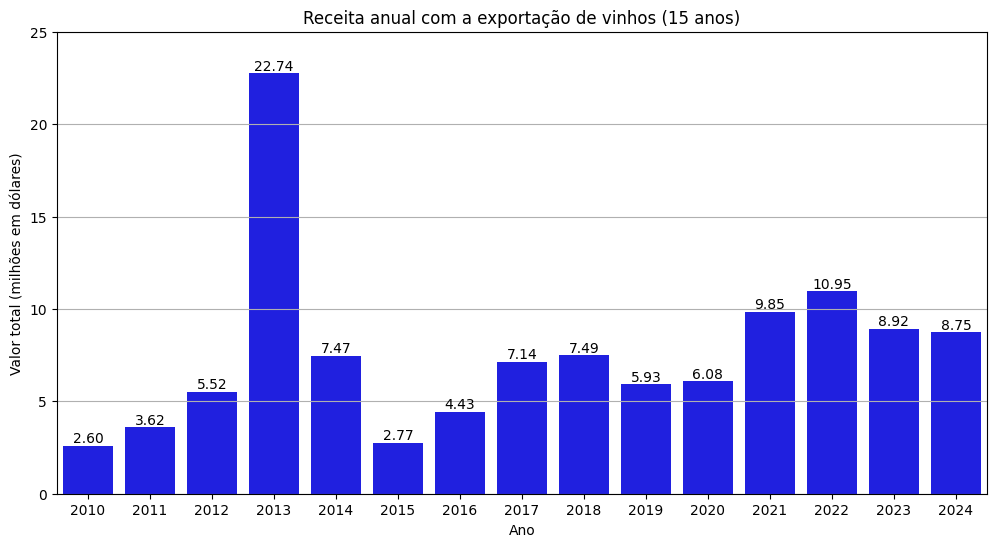

In [ ]:
# plota o campo 'Valor' por ano
plota_por_ano('Valor', 'Valor total (milhões em dólares)', 'Receita anual com a exportação de vinhos (15 anos)', 25)

<p>Assim como é perceptível o grande aumento na quantidade de exportação, e na receita no período de 2013, a queda drástica no ano seguinte também é um fator intrigante. E também existem diversos fatores que podem ter influenciado nesse retrato, como:</p>

<ul>
    <li><a href='https://www.estadao.com.br/paladar/bebida/clima-extremo-reduz-safra-2014/?utm_source=chatgpt.com'>Condições climáticas desfavoráveis que resultaram em queda de 20% da produção nacional;</a></li>
    <li><a href='https://economia.uol.com.br/cotacoes/noticias/redacao/2014/12/30/dolar-sobe-13-no-ano-nos-4-anos-de-dilma-salta-60-de-r-167-a-r-266.htm?utm_source=chatgpt.com'>Aumento drástico na valorização do Dólar e incertezas políticas, podem ter gerado desconfiança do mercado internacional frente ao Brasil. </a></li>
</ul>


In [ ]:
# plota o campo 'Quantidade' por ano
plota_por_ano('Quantidade', 'Valor total (milhões de litros)', 'Quantidade anual de vinho exportado (15 anos)', 25)

<p>Com relação a quantidade de litros de vinhos exportados, é possível analisar que à partir de 2016, houve uma retomada no crescimento da quantidade exportada, de forma bem moderada. Isso pode ter sido produto de diversos fatores como:</p>
<ul>
    <li><a href='https://istoedinheiro.com.br/vinhos-brasileiros-da-dificil-safra-de-2016-sao-avaliados-por-especialistas/'>Piora na qualidade dos vinhos brasileiros devido a continuação de desfavorecimentos climáticos;</a></li>
    <li><a href='https://istoedinheiro.com.br/producao-mundial-de-vinho-cai-32-em-2016/'>Queda de 3,2% na produção mundial de vinhos;</a></li>
    <li><a href='https://www12.senado.leg.br/noticias/materias/2016/12/28/impeachment-de-dilma-rousseff-marca-ano-de-2016-no-congresso-e-no-brasil'>O impeachment da ex-presidente Dilma Roussef pode também ter sido uma influência, pois o ocorrido gerou grandes impactos socio-econômicos.</a></li>
</ul>

In [ ]:
# plota a média anual de litros exportados durante 15 anos
valor_medio_litro = anos_recente.groupby('Ano')['Valor'].sum() / anos_recente.groupby('Ano')['Quantidade'].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_ylim(0, 4)
ax.set_xticks(valor_medio_litro.index)
ax.grid(axis='y')
ax.set_xlabel('Ano')
ax.set_ylabel('Valor médio por litro (em dólares)')
ax.set_title('Valor médio por litro de vinho exportado (15 anos)')

bars = ax.bar(valor_medio_litro.index, valor_medio_litro.values)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{height:.2f}',
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

<p>No gráfico acima é possível identificar que, o ano de 2012 foi o que teve o menor valor médio por litro de vinho exportado, alcançado o valor de USD 0,96. Dessa forma, fez-se necessário exportar uma quantidade muito maior de vinho para manter o ritmo de crescimento da receita em comparação aos anos anteriores. Isso teve provavelmente influência de vários fatores, mas um dos principais que pode ter tornado o vinho brasileiro mais competitivo no mercado mundial, é o valor da cotação do dólar que havia sofrido um aumento de 17,37% com relação ao ano anterior, chegando na casa dos R$ 1,96. Pode-se considerar uma piora na qualidade do vinho brasileiro naquela época, para ter tido um retorno tão baixo. Porém, nos anos seguintes o valor do litro se manteve numa média razoável, possibilitando ter um maior retorno financeiro com uma menor quantidade exportada.</p>

In [ ]:
# plota o top 5 países destino de exportação durante 15 anos
top_5_paises = (anos_recente.groupby('País')['Valor'].sum().sort_values(ascending=False).head(5).index)
top_df = anos_recente[anos_recente['País'].isin(top_5_paises)]
df_pivot = top_df.pivot_table(index='Ano', columns='País', values='Valor', aggfunc='sum')
df_pivot = df_pivot / 1_000_000
ordem_colunas = df_pivot.sum().sort_values(ascending=False).index
df_pivot = df_pivot[ordem_colunas]
fig, ax = plt.subplots(figsize=(12, 6))
df_pivot.plot(ax=ax)
ax.set_xticks(df_pivot.index)
ax.set(xlabel='Ano', ylabel='Valor exportado (milhões de dólares)', title='Top 5 países de destino das exportações de vinhos brasileiros (15 anos)')
ax.grid()
ax.set_ylim(0, 16)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='País', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

<p>O gráfico acima nos traz uma visão ampla, de como foi a evolução da exportação de vinhos do Brasil, e é possível levantar uma prospecção em cima dessas informações.

É possível identificar o Paraguai tem sido o país mais rentável em todo o período de 15 anos, e que teve um crescimento contínuo nos últimos anos. Logo em seguida temos a Rússia que teve um enorme pico em 2013 por conta das políticas de escoamento da reserva de vinho, porém nos anos seguintes se manteve num patamar próximo de 0, portanto, considerando os anos mais recentes e a situação de guerra, o país não se faz uma boa opção de prospecção atualmente.

Portanto, com um dos principais países que foi protagonista de importação do vinho brasileiro durante um período que está fora de cogitação, é necessário recorrer aos demais países que possuem fortes relações com o Brasil, como os Estados Unidos que possui um histórico sólido com relação a importação de vinho brasileiro. Porém, com uma produção que ainda está se recuperando das violentas enchentes em 2024 no Rio Grande do Sul, e as sanções de tarifas de 10% impostas por Donald Trump para os produtos brasileiros, espera-se uma diminuição considerável nas comercializações com os EUA.

É possível dizer que o Reino Unido e a China, são países mesmo com o histórico moderado de importação de vinho, são clientes sólidos e que devem ser mantidos no alto patamar. Principalmente a China, que nos últimos anos fortaleceu muito as relações com o Brasil.</p>  

In [ ]:
# plota a relação entre quantidade exportada e a cotação do dólar
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(anos_recente.groupby('Ano')['Quantidade'].sum() / 1_000_000, ultima_cotacao_ano.values)
ax.set_ylim(0, 6)
ax.set_xlabel('Quantidade exportada')
ax.set_ylabel('Cotação do dólar')
ax.set_title('Relação entre quantidade exportada e cotação média do dólar (15 anos)')
plt.show()

<p>O gráfico acima compara a relação que existe entre a cotação do dólar e quantidade exportada, para entender o nível que esse critério de encontra. E é possível identificar que há uma relação mínima entre o preço do dólar e a quantidade comprada por cada país. Ou seja, a quantidade pode estar relacionada muito mais com questões de qualidade do vinho, questões culturais, demanda, entre diversos outros fatores que devem ser analizados para identificar um padrão nas comercializações.</p>

In [ ]:
# plota um ranking top 20 países que mais importaram o vinho brasileiro
valores_por_pais = (anos_recente.groupby('País')['Valor'].sum() / 1_000_000)
valores_por_pais = valores_por_pais[valores_por_pais > 0].sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(valores_por_pais.index[::-1], valores_por_pais.values[::-1])

for i, (valor, pais) in enumerate(zip(valores_por_pais.values[::-1], valores_por_pais.index[::-1])):
    ax.text(valor + 0.1, i, f'{valor:.2f}', va='center', fontsize=9)

ax.set_xlim(0, 50)
ax.set_xlabel('Valor Total (milhões de Dólares)')
ax.set_ylabel('País')
ax.set_title('Top 20 países com maiores valores de exportação de vinho (15 anos)')
plt.tight_layout()
plt.show()

<p>O gráfico "Top 20 países com maiores valores de exportação de vinho (15 anos)" auxilia na decisão de prospecção, mostrando com dados históricos quais são os países que tiveram mais interesse no vinho brasileiro nos últimos anos, e que podem ser reconquistados de alguma forma, para que tornem a consumir do vinho brasileiro.</p>

## Conclusão

<p>Ao longo dos últimos 15 anos, a exportação de vinhos brasileiros demonstrou flutuações significativas, fortemente influenciadas por fatores climáticos, econômicos e estratégicos. O ano de 2013 se destacou com o maior volume e valor exportado, marcando um ponto fora da curva, enquanto 2014 apresentou o maior valor médio por litro, refletindo um possível reposicionamento do produto ou efeito de escassez produtiva.

A análise dos dados por país revelou uma concentração crescente das exportações no mercado paraguaio, além de países sul-americanos vizinhos, com menor participação de destinos mais exigentes como EUA e Europa. Isso reforça a importância de alinhar o portfólio de produtos às preferências dos principais mercados atuais.

Adicionalmente, observou-se uma relação visível entre a cotação do dólar e o volume exportado: anos com dólar mais valorizado coincidem com crescimento das exportações, o que evidencia a sensibilidade do setor ao câmbio.

O ranking dos países importadores mostra ainda oportunidades claras de expansão e diversificação, enquanto os gráficos de valor médio indicam um avanço na precificação, especialmente em anos de menor oferta, como 2014 e 2024.

Portanto, a continuidade da expansão das exportações de vinho brasileiro dependerá da capacidade do setor em:

<ul>
<li>Manter qualidade em meio a instabilidades climáticas;</li>
<li>Investir em inteligência comercial e logística;</li>
<li>Adaptar-se às exigências regulatórias dos mercados mais rentáveis;</li>
<li>E, sobretudo, diversificar seus destinos e canais de distribuição.</li>
</ul>
</p>